<a href="https://colab.research.google.com/github/nguyentkfsc0086/heart-diesease-classification/blob/nguyen/Nguyen_script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
# import the needed libraries
import kagglehub
import pandas as pd
import os, glob
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# Load the dataset

In [14]:
# Load the dataset directory
dataset_dir = kagglehub.dataset_download("neurocipher/heartdisease")
print("Dataset directory:", dataset_dir)

# Find CSV files inside it
csv_files = glob.glob(os.path.join(dataset_dir, "**", "*.csv"), recursive=True)
print("CSV files found:", csv_files)

# Read one (pick the right one if there are multiple)
df = pd.read_csv(csv_files[0])

Using Colab cache for faster access to the 'heartdisease' dataset.
Dataset directory: /kaggle/input/heartdisease
CSV files found: ['/kaggle/input/heartdisease/Heart_Disease_Prediction.csv']


# Overview of the dataset

## Quick analysis

In [15]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


- Check if there is any `null` values across the dataset

In [17]:
# check if there is any null values across the dataset
df.isna().sum()

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


There is no `null` values so I think we can move to the regression models

# Doing logistic regression

## Split the data into train and test

In [19]:
# split the features and the results from the big dataset
y = df['Heart Disease']
X = df.drop('Heart Disease', axis=1)
# split into train and test set - 75% for training and 25% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,)

In [20]:
# import the model
logreg = LogisticRegression(random_state=16)
# train the model with the data
logreg.fit(X_train, y_train)
# predit with the test dataset
y_pred = logreg.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
accuracy_score(y_test, y_pred)


0.8823529411764706

In [22]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[26,  3],
       [ 5, 34]])

Text(0.5, 427.9555555555555, 'Predicted label')

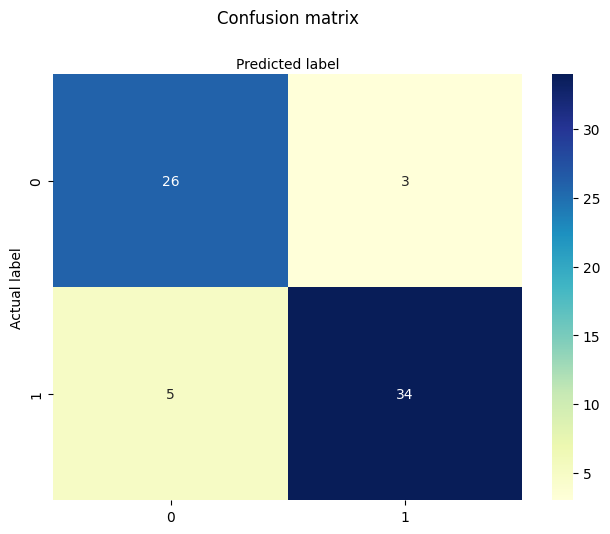

In [26]:

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')